/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

각 폴드별 정확도: [0.86592179 0.85393258 0.81460674 0.82022472 0.84831461]
평균 정확도: 84.06%
표준 편차(안정성): 0.0198
XGBoost 평균 정확도: 84.06%


/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/studyAIBasic/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [15:05:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite

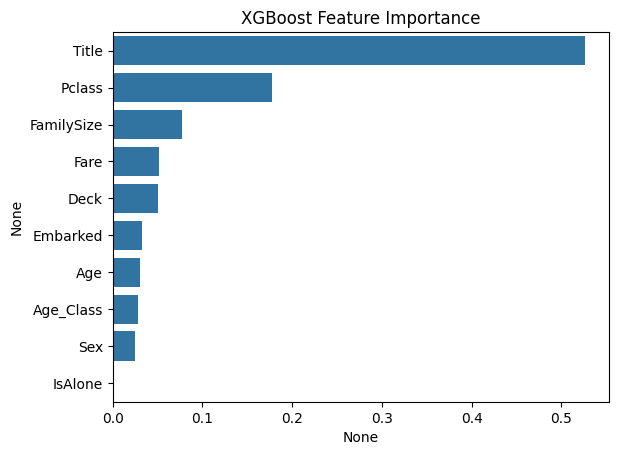

AttributeError: 'numpy.ndarray' object has no attribute 'predict'

In [10]:

import pandas as pd
import numpy as np
#!pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

#!pip install matplotlib
#!pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns

#print(xgb.__version__)

# 1. 데이터 로드
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

def transform_data(df):
    # A. Title 추출
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
    df['Title'] = df['Title'].map(title_mapping).fillna(0)
    
    # B. 결측치 처리 (중앙값/최빈값)
    df['Age'] = df['Age'].fillna(train_df['Age'].median())
    df['Fare'] = df['Fare'].fillna(train_df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna('S')
    
    # C. 수치화 및 인코딩
    df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # D. 새로운 피처 생성 (FamilySize, IsAlone)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # E. [전략 1] Deck 추출 (Cabin의 첫 글자)
    df['Deck'] = df['Cabin'].str.slice(0, 1).fillna('U')
    deck_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "T": 8, "U": 0}
    df['Deck'] = df['Deck'].map(deck_mapping)
    
    # F. [전략 2] Age * Pclass 상호작용 피처
    df['Age_Class'] = df['Age'] * df['Pclass']
    
    return df

# 전처리 실행
train_data = transform_data(train_df)
test_data = transform_data(test_df)

# 학습 데이터 구성
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'Deck', 'Age_Class']
X = train_data[features]
y = train_data['Survived']

# 아까 찾은 최적의 하이퍼파라미터 적용 (GridSearch 결과 반영)
# n_estimators, max_depth 등 -> best_params_ 값 입력
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05, # 너무 빠르지 않게 조금씩 학습
    max_depth=4,        # 나무 깊이 제한
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# 교차 검증 객체 생성 (5번 쪼개기, 데터 섞기 포함)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 교차 검증 수행, 정확도 기준으로 평가
cv_results = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')

# 결과 출력
print(f"각 폴드별 정확도: {cv_results}")
print(f"평균 정확도: {cv_results.mean() * 100:.2f}%")
print(f"표준 편차(안정성): {cv_results.std():.4f}")

# 다시 교차 검증으로 성능 비교
xgb_cv_results = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')
print(f"XGBoost 평균 정확도: {xgb_cv_results.mean() * 100:.2f}%")

xgb_model.fit(X, y)
feature_imp = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title("XGBoost Feature Importance")
plt.show()

# 제출 파일 생성
predictions = xgb_cv_results.predict(test_data[features])

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions
})
submission.to_csv('submission_final_85.csv', index=False)
print("✅ 제출 파일(submission_final_85.csv)이 생성되었습니다!")